In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

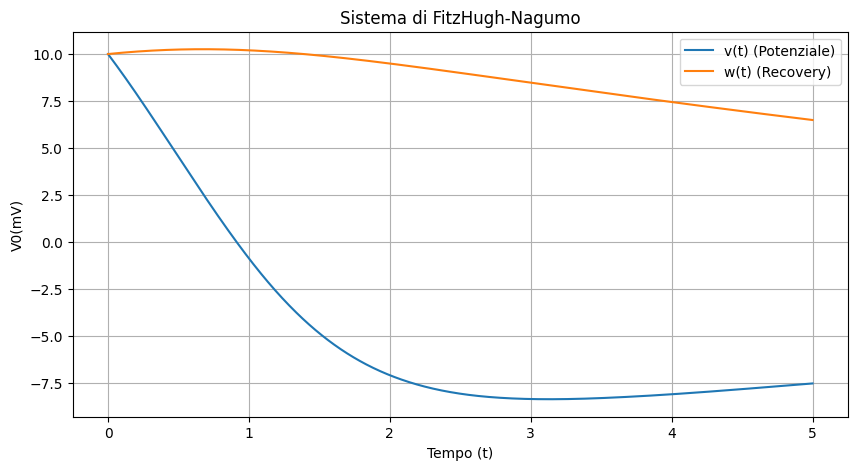

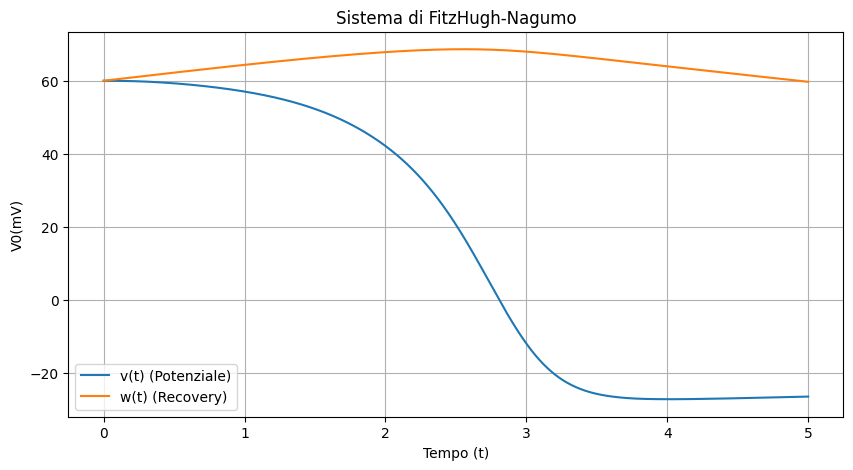

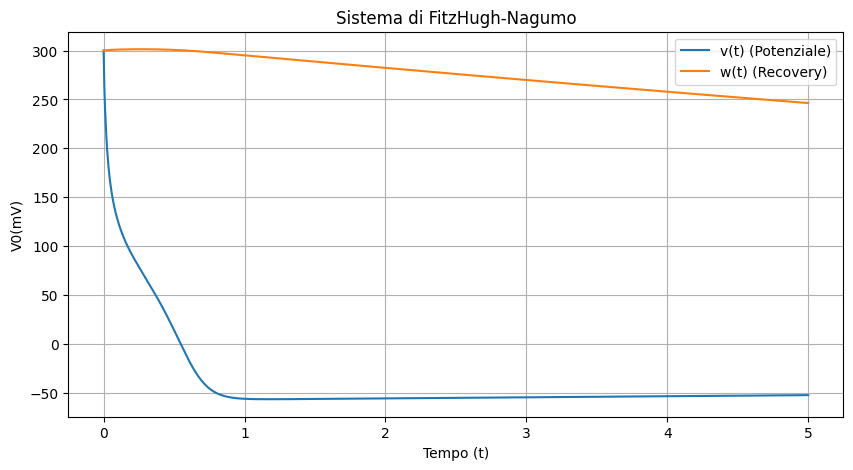

In [2]:
## Approssimazione numerica in 0D

def FHN(t, y):
    v, w = y
    dvdt = b * v * (v - beta) * (delta - v) - c * w + I_app 
    dwdt = e * (v - gamma * w)
    return [dvdt, dwdt]

#Params 
I_app = 0
b = 5
c = 1
beta = 0.1
delta = 1
gamma = 0.25 
e = 0.1 

### Assumo
v0_list = [0.1, 0.6,3]

T = 5

t = np.linspace (0, T, 1000)



## I_ app = 0 
for j in v0_list: 
    w0 = j
    y0 = [j, j]
    sol = solve_ivp(FHN, [0, T], [j, w0], t_eval=t)
    plt.figure(figsize=(10, 5))
    plt.plot(t, sol.y[0]*100, label='v(t) (Potenziale)')
    plt.plot(t, sol.y[1]*100, label='w(t) (Recovery)')
    plt.xlabel('Tempo (t)')
    plt.ylabel('V0(mV)')
    plt.title('Sistema di FitzHugh-Nagumo')
    plt.legend()
    plt.grid()
plt.show()


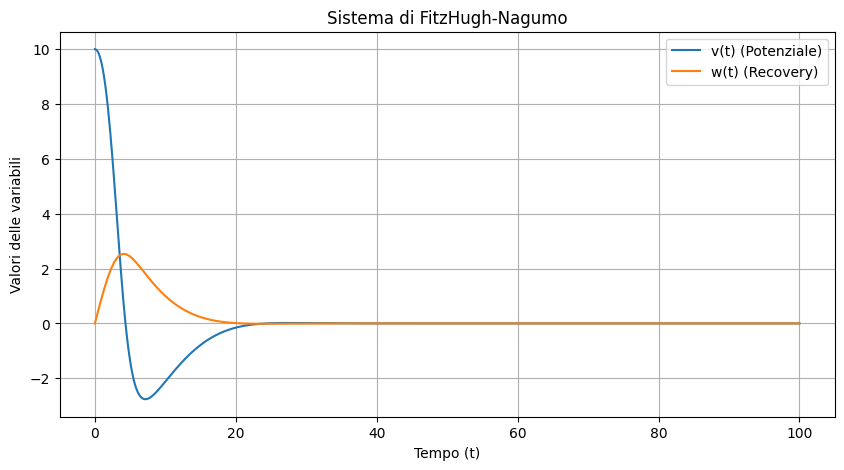

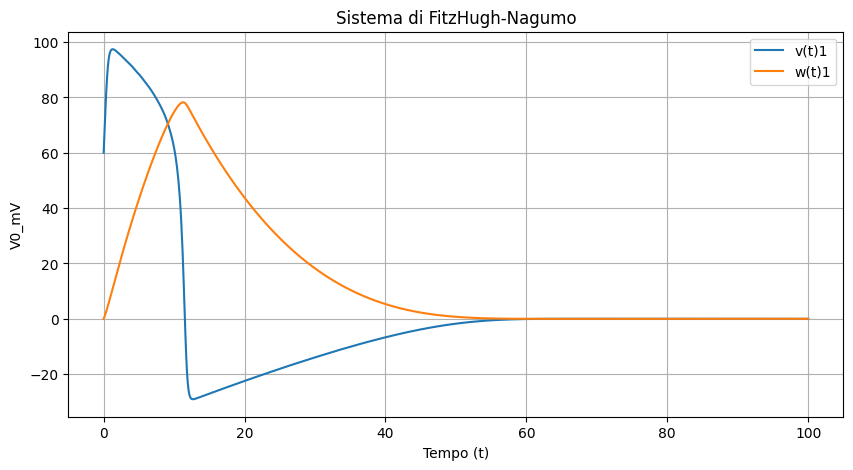

In [3]:
#Analysis on v0, w0

v0, w0, T  = 0.1, 0, 100
v01, w01, T = 0.6, 0, 100
t = np.linspace (0, T, 1000)

sol = solve_ivp(FHN, [0, T], [v0, w0], t_eval=t)
sol1 = solve_ivp(FHN, [0, T], [v01, w01], t_eval=t)

plt.figure(figsize=(10, 5))
plt.plot(t, sol.y[0]*100, label='v(t) (Potenziale)')
plt.plot(t, sol.y[1]*100, label='w(t) (Recovery)')
plt.xlabel('Tempo (t)')
plt.ylabel('Valori delle variabili')
plt.title('Sistema di FitzHugh-Nagumo')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, sol1.y[0]*100, label='v(t)1')
plt.plot(t, sol1.y[1]*100, label='w(t)1')
plt.xlabel('Tempo (t)')
plt.ylabel('V0_mV')
plt.title('Sistema di FitzHugh-Nagumo')
plt.legend()
plt.grid()
plt.show()

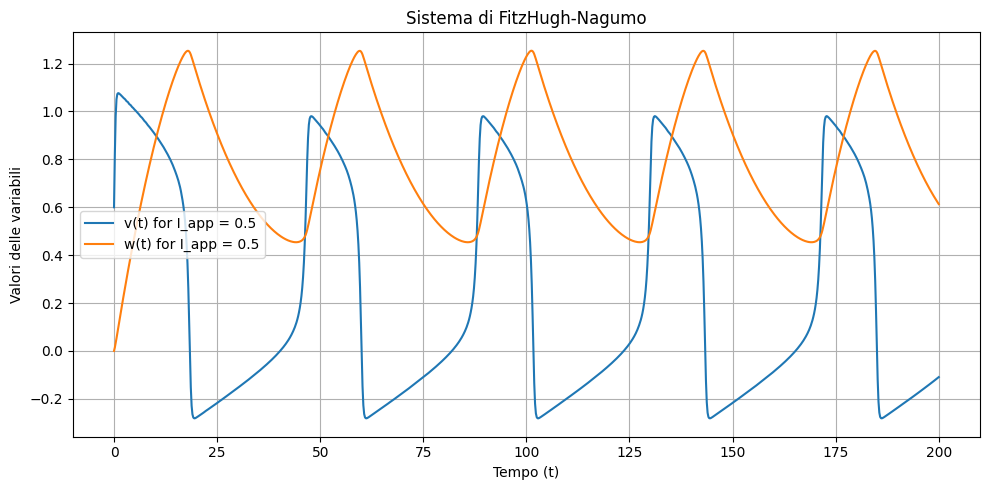

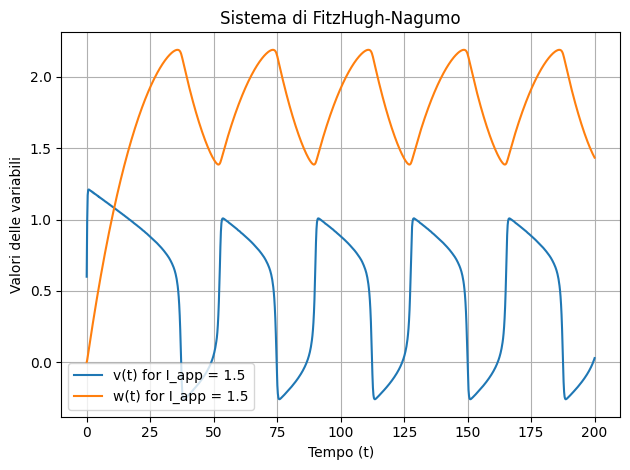

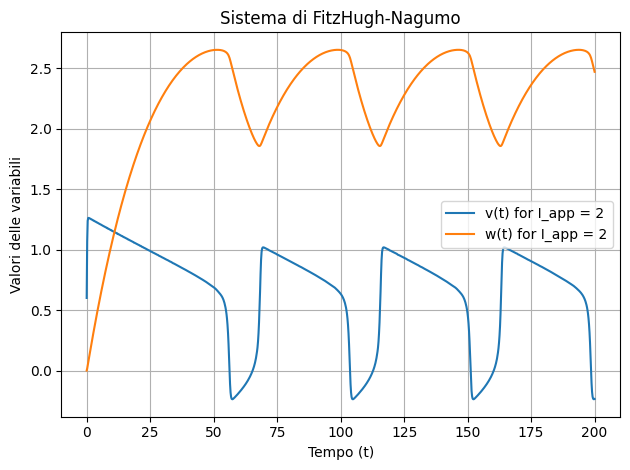

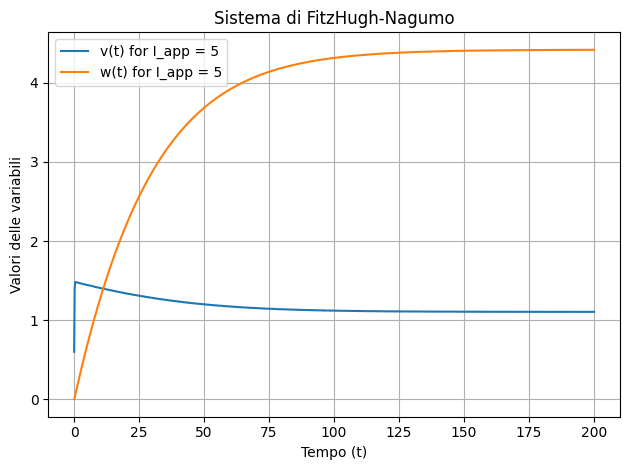

In [4]:
#Analysis on I_app

I_app_list = [0.5, 1.5, 2,5]
T = 200
t = np.linspace(0,T, 1000)
v0, w0 = 0.6, 0

plt.figure(figsize=(10, 5))

for I_app in I_app_list:
    sol3 = solve_ivp(FHN, [0,T], [v0, w0], t_eval=t)
    
    plt.plot(t, sol3.y[0], label=f'v(t) for I_app = {I_app}')
    plt.plot(t, sol3.y[1], label= f'w(t) for I_app = {I_app}')
    plt.xlabel('Tempo (t)')
    plt.ylabel('Valori delle variabili')
    plt.title('Sistema di FitzHugh-Nagumo')
    plt.grid()
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5)) 
    plt.tight_layout()  # Aggiusta gli spazi per evitare sovrapposizioni    
    plt.show()

## ho superato il valore soglia V= alpha ?? 
# per i_app >>> ho un solo PA perchè non torno più a valori bassi del Vm , mi serve la fase 
# di iperpol per generare un altro PA 

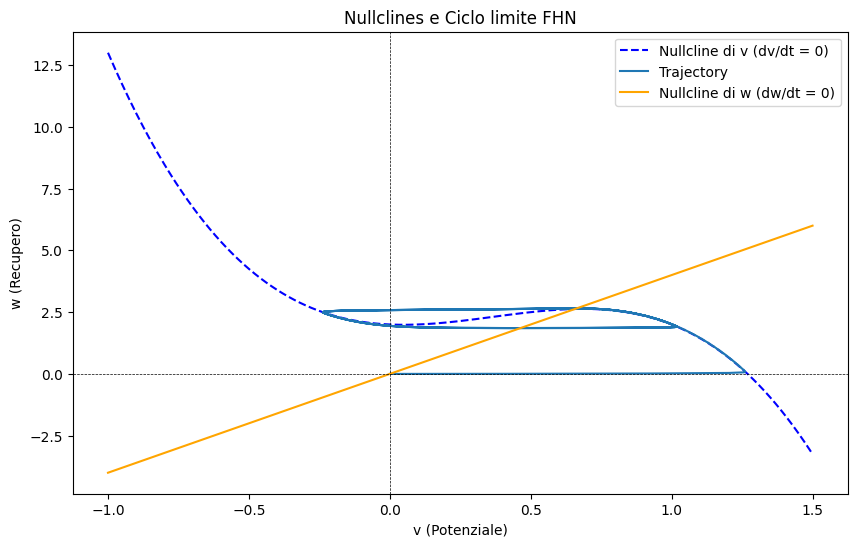

In [23]:
# Orbite prodotte e nullclines per (a) e (b) 

## g( v, w) == b * v * (v - beta) * (delta - v) - c * w + I_app = 0  ##lookin for SS
# w = 1/ C * (b * v * (v - beta) * (delta - v) + I_app))
# w =  g(v) 

############## FOR I APP = 0
## nullcline di u: w = f(u)
## nullcline di w = u/ gamma 

I_app, b, c, beta, delta, gamma, e = 2, 5, 1, 0.1, 1, 0.25, 0.1
#I_app, b, c, beta, delta, gamma, e = 4, 1, 3, 0.2, 2, 0.25, 2 
t = np.linspace(0, 200, 1000)
sol = solve_ivp(FHN, [0, 200], [0, 0], t_eval=t)
#plt.plot( t, sol.y[0], label=("v(t)"))
#plt.legend()
#plt.show()


# Nullcline di v (dv/dt = 0)
def nullcline_v(v):
    return (b * v * (v - beta) * (delta - v) + I_app) / c

# Nullcline di w (dw/dt = 0)
def nullcline_w(v):
    return v / gamma

v = np.linspace(-1, 1.5, 500) 
w_v = nullcline_v(v)
w_w = nullcline_w(v)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(v, w_v, label="Nullcline di v (dv/dt = 0)", color='blue', linestyle = "--")
plt.plot(sol.y[0], sol.y[1], label= "Trajectory")
plt.plot(v, w_w, label="Nullcline di w (dw/dt = 0)", color='orange')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel("v (Potenziale)")
plt.ylabel("w (Recupero)")
plt.title("Nullclines e Ciclo limite FHN")
plt.legend()

plt.show()